In [1]:
# リカレントニューラルネットワーク（RNN)
# 確率と言語モデル
# word2vecを確立の視点から眺める
# 言語モデル
# CBOWモデルを言語モデルに？
# RNNとは
# 循環するニューラルネットワーク
# ループの展開
# Backpropagation Through Time
# Truncated BPTT
# Truncated BPTTのミニバッチ学習

In [3]:
# RNNの実装
# RNNレイヤの実装
import numpy as np

class RNN:
    def __init__(self, Wx, Wh, b):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.cache = None

    def forward(self, x, h_prev):
        Wx, Wh, b = self.params
        t = h_prev @ Wh + x @ Wx + b
        h_next = np.tanh(t)

        self.cache = (x, h_prev, h_next)
        return h_next

    def backward(self, dh_next):
        Wx, Wh, b = self.params
        x, h_prev, h_next = self.cache

        dt = dh_next * (1 - h_next ** 2)
        db = np.sum(dt, axis=0)
        dWh = h_prev.T @ dt
        dh_prev = dt @ Wh.T
        dWx = x.T @ dt
        dx = dt @ Wx.T

        self.grads[0][...] = dWx
        self.grads[1][...] = dWh
        self.grads[2][...] = db

        return dx, dh_prev


In [6]:
# Time RNNレイヤの実装
from tkinter import NO


class TimeRNN:
    def __init__ (self, Wx, Wh, b, stateful=False):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh)]
        self.layers = None

        self.h, self.dh = None, None
        self.stateful = stateful

    def set_state(self, h):
        self.h = h

    def reset_state(self):
        self.h = None

    # 順伝播の実装
    def forward(self, xs):
        Wx, Wh, b = self.params
        N, T, D = xs.shape
        D, H = Wx.shape

        self.layers = []
        hs = np.empty((N, T, H), dtype="f")

        if not self.stateful or self.h is None:
            self.h = np.zeros((N. H), dtype="f")

        for t in range(T):
            layer = RNN(*self.params)
            self.h = layer.forward(xs[:, t, :], self.h)
            hs[:, t, :] = self.h
            self.layers.append(layer)

        return hs

    # 逆伝播の実装
    def backward(self, dhs):
        Wx, Wh, b = self.params
        N, T, H = dhs.shape
        D, H = Wx.shape

        dxs = np.empty((N, T, D), dtype="f")
        dh = 0
        grads = [0, 0, 0]
        for t in reversed(range(T)):
            layer = self.layers[t]
            dx, dh = layer.backward(dhs[:, t, :] + dh) # 合算した勾配
            dxs[:, t, :] = dx

            for i, grad in enumerate(layer.grads):
                grads[i] += grad

        for i, grad in enumerate(grads):
            self.grads[i][...] = grad
        self.dh = dh

        return dxs

In [7]:
# 時系列データを扱うレイヤの実装
# RNNLMの全体像
# Timeレイヤの実装

In [10]:
# RNNLMの実装
import sys
sys.path.append("..")
import numpy as np
from common.time_layers import *

rng = np.random.default_rng()

class SimpleRnnlm:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = rng.random()

        # 重みの初期化
        embed_W = (rn(V, D) / 100).astype("f")
        rnn_Wx = (rn(D, H) / np.sqrt(D)).astype("f")
        rnn_Wh = (rn(H, H) / np.sqrt(H)).astype("f")
        rnn_b = np.zeros(V).astype("f")
        affine_W = (rn(H, V) / np.sqrt(H)).astype("f")
        affine_b = np.zeros(V).astype("f")

        # レイヤの生成
        self.layers = [
            TimeEmbedding(embed_W),
            TimeRNN(rnn_Wx, rnn_Wh, rnn_b, stateful=True),
            TimeAffine(affine_W, affine_b)
        ]
        self.loss_layer = TimeSoftmaxWithLoss()
        self.rnn_layer = self.layers[1]

        # 全ての重みと勾配をリストにまとめる
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

    # forward()メソッド、backward()メソッドの実装
    def forward(self, xs, ts):
        for layer in self.layers:
            xs = layer.forward(xs)
        loss = self.loss_layer.forward(xs, ts)
        return loss
    
    def backward(self, dout=1):
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

    def reset_state(self):
        self.rnn_layer.reset_state()


In [11]:
# 言語モデルの評価

corpus size: 1000, vocabulary size: 418
| epoch 1 | perplexity 369.35
| epoch 2 | perplexity 251.95
| epoch 3 | perplexity 226.27
| epoch 4 | perplexity 216.25
| epoch 5 | perplexity 207.77
| epoch 6 | perplexity 202.45
| epoch 7 | perplexity 199.55
| epoch 8 | perplexity 196.35
| epoch 9 | perplexity 192.11
| epoch 10 | perplexity 192.59
| epoch 11 | perplexity 188.42
| epoch 12 | perplexity 192.26
| epoch 13 | perplexity 189.79
| epoch 14 | perplexity 190.45
| epoch 15 | perplexity 189.16
| epoch 16 | perplexity 185.34
| epoch 17 | perplexity 183.07
| epoch 18 | perplexity 180.79
| epoch 19 | perplexity 181.38
| epoch 20 | perplexity 182.68
| epoch 21 | perplexity 181.35
| epoch 22 | perplexity 178.88
| epoch 23 | perplexity 174.18
| epoch 24 | perplexity 176.43
| epoch 25 | perplexity 174.26
| epoch 26 | perplexity 173.12
| epoch 27 | perplexity 167.41
| epoch 28 | perplexity 169.46
| epoch 29 | perplexity 163.66
| epoch 30 | perplexity 158.99
| epoch 31 | perplexity 159.88
| epoch 

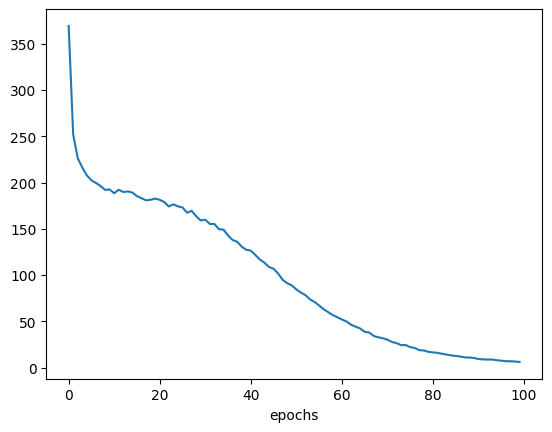

In [12]:
# RNNLMの学習コード
import sys

import matplotlib.pyplot as plt
import numpy as np
from ch05.train_custom_loop import offset
from common import optimizer
from common.optimizer import SGD
from dataset import ptb
from simple_rnnlm import SimpleRnnlm

# ハイパーパラメータの設定
batch_size = 10
wordvec_size = 100
hidden_size = 100
time_size = 5
lr = 0.1
max_epoch = 10

# 学習データの読み込み
corpus, word_to_id, id_to_word = ptb.load_data("train")
corpus_size  =1000
corpus = corpus[:corpus_size]
vocab_size = int(max(corpus) + 1)

xs = corpus[:-1]
ts = corpus[1:]
data_size = len(xs)
print("corpus size: %d, vocabulary size: %d" % (corpus_size, vocab_size))

# 学習時に仕様する変数
max_iters = data_size // (batch_size * time_size)
time_idx = 0
total_loss = 0
loss_count = 0
ppl_list = []

# モデルの生成
model = SimpleRnnlm(vocab_size, wordvec_size, hidden_size)
optimizer = SGD(lr)

jump = (corpus_size - 1) // batch_size
offsets = [i * jump for i in range(batch_size)]

for epoch in range(max_epoch):
    for iter in range(max_iters):
        # ミニバッチの取得
        batch_x = np.empty((batch_size, time_size), dtype="i")
        batch_t = np.empty((batch_size, time_size), dtype="i")
        for t in range(time_size):
            for i, offset in enumerate(offsets):
                batch_x[i, t] = xs[(offset + time_idx) % data_size]
                batch_t[i, t] = ts[(offset + time_idx) % data_size]

        # 勾配を求め。パラメータを更新
        loss = model.forward(batch_x, batch_t)
        model.backward()
        optimizer.update(model.params, model.grads)
        total_loss += loss
        loss_count += 1

    # エポックごとにパープレキシティの評価
    ppl = np.exp(total_loss / loss_count)
    print("| epoch %d | perplexity %.2f" % (epoch+1, ppl))
    total_loss, loss_count=0, 0

In [ ]:
# RNNLMのTrainerクラス
